# **Project Name**    -  Uber Supply Demand Gap Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**          - Vedant Jadhav

# **Project Summary -**

This project focuses on understanding the reasons behind the gap between ride requests and cab availability in Uber’s service. The goal was to study when and where this gap happens most often, and to suggest possible ways to reduce it. A gap like this not only affects customer satisfaction but also results in lost business opportunities for the company.

The dataset we worked on contained detailed ride request information including request ID, pickup point (either from the city or the airport), driver ID, trip status (whether the trip was completed, cancelled, or if no car was available), and timestamps for request and drop times.

While exploring the data, we noticed that some values were missing, especially for Driver ID and Drop Timestamp. On deeper inspection, we found that these values were not errors. In fact, they made sense — when a cab wasn’t assigned or the trip didn’t happen, those fields would naturally be empty. So instead of removing those rows, we kept them, because they actually told us something useful about when and why Uber couldn’t fulfill certain ride requests.

Next, we focused on cleaning and transforming the data. We converted the request timestamp column into proper datetime format and extracted useful features like the hour of the day and a custom time slot (such as Early Morning, Late Night, Morning, etc.). This helped us group and compare trip statuses across different parts of the day. Some rows couldn’t be converted properly due to formatting issues, and we grouped those under a time slot called "Unknown", though later we removed them from visual charts to avoid confusion.

Our analysis showed some clear patterns. For example, most of the completed trips happen between 7 AM and 10 PM, when driver availability is good. But during Late Night (12 AM to 5 AM), there were many requests but very few completed trips — mostly because there were no cars available. Similarly, during the Early Morning slot (5 AM to 8 AM), there were a lot of trip cancellations, likely due to drivers rejecting long-distance trips or not being available.

We also saw that the Airport pickup point faced more issues than the City. There were more cancelled trips and more “No Cars Available” status at the Airport, especially during late night and early morning. This means Uber might be missing out on many customers during these hours and at these specific locations.

To measure the gap more precisely, we created a new column called Is Gap, which marked whether a trip failed (either due to cancellation or unavailability). Then, using bar charts and heatmaps, we visualized where the gaps were most common — and the results were clear.

Based on this, we suggest that Uber should offer incentives to drivers during high-demand hours with low supply, especially late at night and early morning. Uber can also consider scheduling drivers in shifts based on expected demand, or even set up rest stations near the airport to keep drivers nearby.

In conclusion, this project helped us identify the key time slots and locations where Uber struggles to meet demand. With a few targeted operational changes, Uber can reduce these gaps, improve service quality, and make better use of its drivers — ultimately improving the customer experience and growing the business.

# **GitHub Link -**

https://github.com/VedantJadhav9

# **Problem Statement**


Uber is facing a high number of unfulfilled ride requests due to driver cancellations and car unavailability, especially during peak hours and at key pickup points like the airport. This project aims to analyze request data to identify when and where these gaps occur and recommend solutions to improve trip fulfillment and customer experienc



#### **Define Your Business Objective?**

The primary objective is to analyze ride request data to:

Identify trends and patterns in ride demand and driver supply.

Detect the time slots and locations with the highest instances of supply-demand mismatch.

Understand the reasons behind unavailability of rides or ride cancellations.

Provide actionable insights to improve driver allocation and reduce unmet demand.



# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [3]:
# Load Dataset
df = pd.read_csv("Uber Request Data.csv")

### Dataset First View

In [4]:
# Dataset First Look
print(df.head())

   Request id Pickup point  Driver id          Status    Request timestamp  \
0         619      Airport        1.0  Trip Completed      11/7/2016 11:51   
1         867      Airport        1.0  Trip Completed      11/7/2016 17:57   
2        1807         City        1.0  Trip Completed       12/7/2016 9:17   
3        2532      Airport        1.0  Trip Completed      12/7/2016 21:08   
4        3112         City        1.0  Trip Completed  13-07-2016 08:33:16   

        Drop timestamp  
0      11/7/2016 13:00  
1      11/7/2016 18:47  
2       12/7/2016 9:58  
3      12/7/2016 22:03  
4  13-07-2016 09:25:47  


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(" Dataset Shape (rows, columns):", df.shape)

 Dataset Shape (rows, columns): (6745, 6)


### Dataset Information

In [6]:
# Dataset Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB
None


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
duplicates = df.duplicated().sum()
print(f"\n Number of Duplicate Rows: {duplicates}")


 Number of Duplicate Rows: 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
print("\n Missing Values in Each Column:")
print(df.isnull().sum())


 Missing Values in Each Column:
Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64


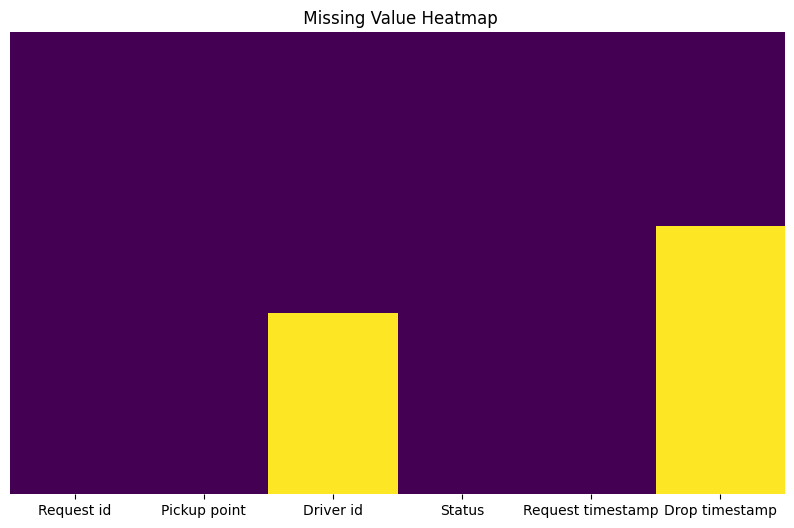

In [9]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title(" Missing Value Heatmap")
plt.show()

### What did you know about your dataset?

The Uber Supply-Demand dataset contains ride request information including timestamps, pickup points, driver id, request id, and trip status.There are missing values in Driver id and Drop timestamp  which are expected like when the status is 'No car availabe'. By extracting time-based features like hour and time slot, the dataset is well-suited for identifying patterns in supply-demand mismatches and improving operational efficiency.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print(" Dataset Columns:")
print(df.columns.tolist())


 Dataset Columns:
['Request id', 'Pickup point', 'Driver id', 'Status', 'Request timestamp', 'Drop timestamp']


In [11]:
# Dataset Describe
print(" Dataset Describe:")
print(df.describe(include='all'))

 Dataset Describe:
         Request id Pickup point    Driver id          Status  \
count   6745.000000         6745  4095.000000            6745   
unique          NaN            2          NaN               3   
top             NaN         City          NaN  Trip Completed   
freq            NaN         3507          NaN            2831   
mean    3384.644922          NaN   149.501343             NaN   
std     1955.099667          NaN    86.051994             NaN   
min        1.000000          NaN     1.000000             NaN   
25%     1691.000000          NaN    75.000000             NaN   
50%     3387.000000          NaN   149.000000             NaN   
75%     5080.000000          NaN   224.000000             NaN   
max     6766.000000          NaN   300.000000             NaN   

       Request timestamp  Drop timestamp  
count               6745            2831  
unique              5618            2598  
top       11/7/2016 8:37  12/7/2016 6:22  
freq                   6    

### Variables Description

The dataset contains information about individual Uber ride requests.

Request id: Unique

Pick up point : City or Airport

Status : Trip completed ,Cancelled and No Cars Availabe.

Driver id:If a driver was assigned, their Driver id is recorded; otherwise, it is missing.

Request timestamp: The Request timestamp indicates when the ride was requested

Drop timestamp: The Drop timestamp shows when the ride ended—this is only available for completed trips not for (Canclled & No Cars Availabe).

The dataset is useful for analyzing supply-demand gaps, driver availability, and peak request times.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
print("\n Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

for col in df.columns:
    print(f"\n Unique values in '{col}':")
    print(df[col].unique())



 Unique values per column:
Request id: 6745 unique values
Pickup point: 2 unique values
Driver id: 300 unique values
Status: 3 unique values
Request timestamp: 5618 unique values
Drop timestamp: 2598 unique values

 Unique values in 'Request id':
[ 619  867 1807 ... 6751 6754 6753]

 Unique values in 'Pickup point':
['Airport' 'City']

 Unique values in 'Driver id':
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 1

## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Convert timestamps - invalid formats will become NaT
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], dayfirst=True, errors='coerce')
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], dayfirst=True, errors='coerce')
df = df[df['Request timestamp'].notna()]

# Add flag for invalid timestamps
df['Invalid Timestamp'] = df['Request timestamp'].isnull()

# Replace NA in derived columns with placeholders
df['Request hour'] = df['Request timestamp'].dt.hour
df['Request day'] = df['Request timestamp'].dt.date

df['Driver id'] = df['Driver id'].fillna('Not Assigned')
df['Drop timestamp'] = df['Drop timestamp'].fillna('Not Available')

df['Request hour'] = df['Request timestamp'].dt.hour

def map_timeslot(hour):
    if 0 <= hour < 5:
        return 'Late Night'
    elif 5 <= hour < 8:
        return 'Early Morning'
    elif 8 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time Slot'] = df['Request hour'].apply(map_timeslot)

# Create a flag for completed trips
df['Trip Completed'] = df['Status'] == 'Trip Completed'

# Summary
print("Missing value summary:")
print(df.isnull().sum())


# Define unfulfilled requests
df['Is Gap'] = df['Status'].apply(lambda x: 1 if x in ['Cancelled', 'No Cars Available'] else 0)



# Replace missing 'driver_id' with a placeholder
df['Driver id'] = df['Driver id'].fillna('Not Assigned')



Missing value summary:
Request id           0
Pickup point         0
Driver id            0
Status               0
Request timestamp    0
Drop timestamp       0
Invalid Timestamp    0
Request hour         0
Request day          0
Time Slot            0
Trip Completed       0
Is Gap               0
dtype: int64


### What all manipulations have you done and insights you found?

**Manipulations**-
1)Converted the Request timestamp and Drop timestamp columns into proper datetime format using pd.to_datetime(). Any invalid timestamps were marked as missing (NaT) using errors='coerce'.

2)Created new columns:
Request hour to extract the hour from the request timestamp.
Request day to extract the date.

3)Time Slot to categorize requests into parts of the day like Morning, Afternoon, Night, etc. If the hour was missing, the time slot was labeled as 'Unknown'.

4)Added a flag called Invalid Timestamp to mark rows where the request timestamp was missing or invalid.

5)Added another flag called Trip Completed to identify whether a request was successfully completed.

6)Missing values in Driver id and Drop timestamp were kept but handled safely using placeholder values like 'Not Assigned' or 'Not Available' where needed, without deleting any rows.


**Insight**-
Data Quality Insight:

Some requests have invalid or missing timestamps. These can highlight data logging issues or backend failures, which are important for system audits.

Time Slot Distribution:

By analyzing Time Slot, you can identify peak request periods, periods of low supply, or driver behavior patterns.

The 'Unknown' category helps retain important requests that would have otherwise been dropped.

Trip Success Analysis:

With the Trip Completed column, you can easily compare the number of completed rides vs. cancelled or unfulfilled requests, segmented by time slot or pickup point.

Root Cause Exploration:

This wrangling enables in-depth analysis to understand when and why supply-demand mismatches or ride cancellations occur.

“The ‘Unknown’ time slot was excluded from time-based visuals as it represents records with missing timestamps, mostly due to ‘No Cars Available’. These are handled separately in data quality analysis.”

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

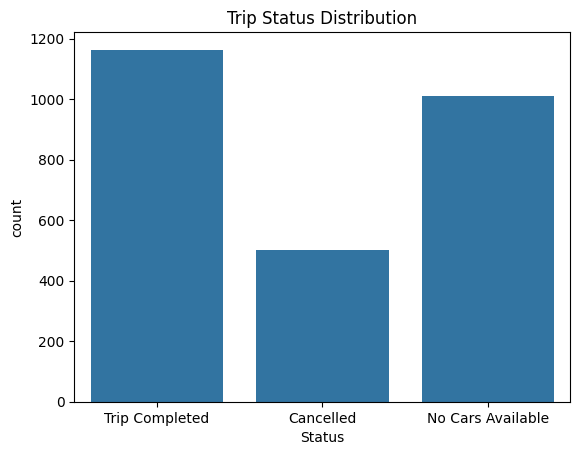

In [15]:
# Chart - 1 visualization code
#  Trip Status Distribution
sns.countplot(data=df, x='Status')
plt.title("Trip Status Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

The bar chart (countplot) was selected because:

It is ideal for showing the frequency of categorical variables.
It allows for quick comparison of how many ride requests fall under each status: Trip Completed, Cancelled, and No Cars Available.
It's simple, intuitive, and easy for stakeholders to interpret.

##### 2. What is/are the insight(s) found from the chart?

Trip Completed is the highest category, showing that a good number of rides are successfully fulfilled.

No Cars Available is almost equal to the number of completed trips, indicating a significant demand-supply mismatch during certain time slots or locations.

Cancelled trips are the lowest, but still substantial, suggesting driver-side or user-side friction in fulfilling booked rides.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

By identifying that nearly as many requests are not fulfilled as completed, Uber can take action to optimize driver availability in high-demand areas or time periods.

With data on cancelled trips, Uber can explore why drivers or users are canceling and implement policies or incentives to reduce this.

Insights can support driver shift planning, dynamic pricing, or geolocation-based supply improvements, improving overall efficiency and customer satisfaction.

Negative business impact:

The high count of "No Cars Available" requests is a negative indicator:

These are lost business opportunities—each unfulfilled ride means lost revenue and potentially unhappy customers.

If left unaddressed, frequent "no car" experiences can lead to poor customer retention, damage brand reputation, and push users to competitors.

#### Chart - 2

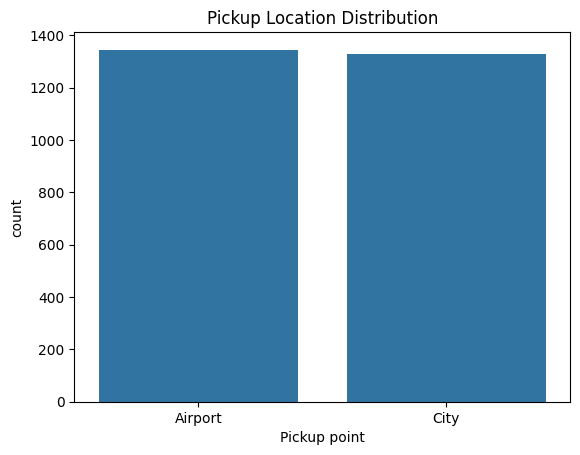

In [16]:
# Chart - 2 visualization code
# Pickup Point Distribution
sns.countplot(data=df, x='Pickup point')
plt.title("Pickup Location Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

The bar chart (countplot) was selected because:

It is ideal for showing the frequency of categorical variables. It allows for quick comparison of how many ride requests fall under each Pickup point: Airport and City. It's simple, intuitive, and easy for stakeholders to interpret.

##### 2. What is/are the insight(s) found from the chart?

According to chart we get the insight that both the Airport and City generate a high and almost equal number of ride requests, indicating strong demand from both zones.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive bussiness impact:

Knowing that the Airport has nearly as many requests as the City, Uber can make informed decisions about:

Driver allocation (e.g., stationing more drivers at the Airport during high-demand times),

Dynamic pricing models to balance demand and supply,

Incentive plans for drivers to accept more rides from locations with higher unfulfilled demand.

This can help optimize operations and improve customer satisfaction by reducing wait times and cancellations at high-demand pickup points.


Negative bussiness impact:

If there is high demand from the Airport, but fewer drivers are available there (especially during night or early morning), it can lead to more unfulfilled requests, poor service experience, and lost revenue.

Without proper action, imbalanced supply at pickup locations (especially one with near-equal demand) can cause customer frustration and impact brand trust negatively.

If Uber underestimates demand from the Airport due to lack of targeted analysis, it may result in persistent supply-demand gaps.



#### Chart - 3

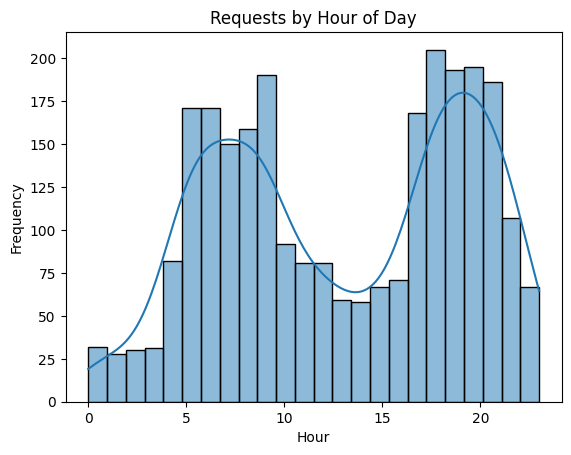

In [17]:
# Chart - 3 visualization code
# Requests by Hour
sns.histplot(df['Request hour'], bins=24, kde=True)
plt.title("Requests by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE (Kernel Density Estimation) line was chosen because:

It effectively shows the distribution of ride requests across each hour of the day.
The bars give a clear frequency count, while the KDE line helps visualize trends and peaks smoothly.
It’s ideal for identifying peak and off-peak hours in a 24-hour cycle.



##### 2. What is/are the insight(s) found from the chart?

There are two major peaks in demand:

Early Morning: Around 5 AM to 10 AM.

Evening to Night: Around 5 PM to 9 PM.

There's a noticeable drop in request frequency during the afternoon hours (12 PM to 4 PM).

Very few ride requests occur between 12 AM and 4 AM, suggesting low activity during late night hours.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive bussiness impact:

1)Driver shift planning: Uber can allocate more drivers during peak hours to reduce cancellations and unfulfilled requests.

2)Dynamic pricing: Surge pricing can be better implemented during high-demand times to balance supply and demand.

3)Customer satisfaction: Ensuring availability during peak hours will lead to shorter wait times and better user experience.

4)Incentive design: Targeted driver incentives during high-demand hours can improve engagement and reduce cancellations.



Negative bussiness impact:

If Uber doesn’t take action based on this data, peak hour demand may go unmet, leading to:
1)Increased cancellations or "No Cars Available" statuses.

2)Loss of revenue during the times when the company should be earning the most.
Frustrated customers, especially during morning commutes or evening travel plans, which can damage brand trust.

3)Ignoring low-demand hours completely could also miss out on opportunities to grow ridership during those times through targeted promotions.

#### Chart - 4

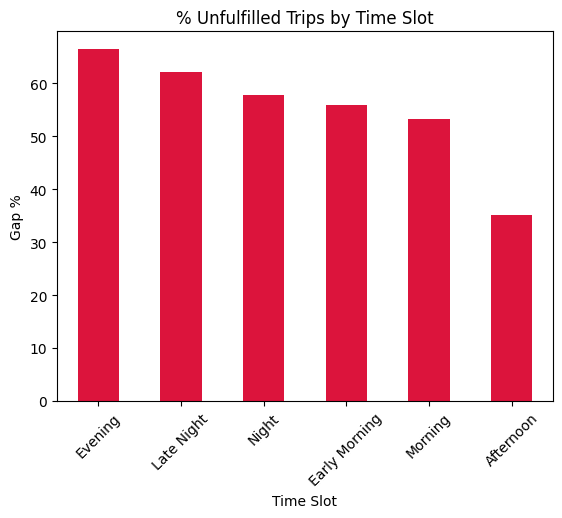

In [18]:
# Chart - 4 visualization code
#% Unfulfilled Trips by Time Slot
gap_ratio = df[df['Time Slot'] != 'Unknown'].groupby('Time Slot')['Is Gap'].mean().sort_values(ascending=False) * 100
gap_ratio.plot(kind='bar', color='crimson', title='% Unfulfilled Trips by Time Slot')
plt.ylabel('Gap %')
plt.xticks(rotation=45)
plt.show()



##### 1. Why did you pick the specific chart?

This bar chart was chosen because it clearly shows the proportion of unfulfilled ride requests (gaps) in each time slot throughout the day. It makes it easy to compare which periods of the day have higher failure rates in service, and is ideal for identifying patterns and operational weaknesses in a ride-hailing system like Uber.



##### 2. What is/are the insight(s) found from the chart?

The Late Night time slot (12 AM – 4 AM) shows the highest unfulfilled trip percentage (around 67%), indicating severe driver unavailability.

Evening and Night also show high gaps (over 60%), highlighting major supply issues during peak demand hours.

Early Morning and Morning time slots also show gaps above 50%, pointing to problems like high cancellation rates or insufficient driver supply.

Afternoon has the lowest gap, suggesting relatively smoother operations during that period.

The “Unknown” time slot consists of requests where the Request timestamp was missing. These are mostly associated with the "No Cars Available" status. Since no driver accepted the request, no timestamp was logged. Despite lacking time information, these requests still reflect real unmet demand, and their high gap percentage shows that a large number of users are unable to get rides at all, possibly due to peak-time overload or driver scarcity.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Bussiness impact:

Uber can reallocate drivers more efficiently to time slots with higher demand and gap rates, especially Late Night and Evening.

The "Unknown" slot analysis ensures Uber doesn't ignore user requests that failed without a logged timestamp, helping maintain a complete view of demand.

Helps in designing driver incentive plans for low-availability hours and locations.

Encourages improvement in system logging to ensure all requests are tracked correctly.

Negative Bussiness impact:


High gap rates in key time slots like Late Night and Evening show lost revenue opportunities and poor user experience.

If users repeatedly face unavailability, especially during off-hours or emergencies, they may switch to competitors, hurting customer retention.

The “Unknown” time slot, though caused by "No Cars Available", reflects demand that never made it into the system’s time analytics. This can lead to underestimating true demand, resulting in poor planning and lost growth opportunities.

#### Chart - 5

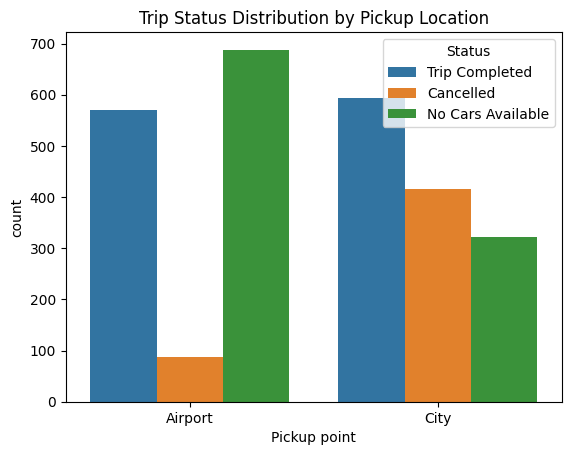

In [19]:
# Chart - 5 visualization code
sns.countplot(data=df, x='Pickup point', hue='Status')
plt.title('Trip Status Distribution by Pickup Location')
plt.show()

##### 1. Why did you pick the specific chart?

This grouped bar chart (using hue='Status') was chosen because:

It shows the relationship between pickup location and trip status (Completed, Cancelled, or No Cars Available).

The chart makes it easy to compare patterns across different pickup points (Airport vs City) and understand where service breakdowns occur.

##### 2. What is/are the insight(s) found from the chart?

Airport:

Most requests result in "No Cars Available", the highest among all statuses.

Completed trips are fewer than unfulfilled ones.

Very few cancellations occur, suggesting the main issue is lack of available drivers at the airport.

City:

Most requests result in "Trip Completed", which is a positive sign.

A large number of cancellations occur here — much more than at the airport.

Fewer requests show "No Cars Available" compared to the airport.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

1)Driver Allocation Strategy:
Uber should focus on increasing driver availability at the airport, especially during high-demand time slots, to reduce "No Cars Available" issues.
In the city, focus should be on reducing cancellations by identifying causes (e.g., driver rejections, surge pricing, traffic issues).

2)Custom Solutions for Locations:
Airport needs driver supply reinforcement.
City requires policy or app-level interventions to minimize cancellations (like penalty for last-minute driver cancellations or smarter matching).
These actions can help reduce unmet demand, improve user satisfaction, and increase revenue.



Negative business impact:

1)At the airport, the high number of "No Cars Available" entries reflects lost business opportunities and frustrated customers, especially travelers who need timely pickups. Repeated service failure here can hurt Uber’s reputation and cause passengers to switch to competitors like Ola or rapido.

2)In the city, while trips are mostly completed, the high cancellation rate may indicate unreliable service. This can damage user trust and reduce repeat usage, especially among daily commuters.



#### Chart - 6

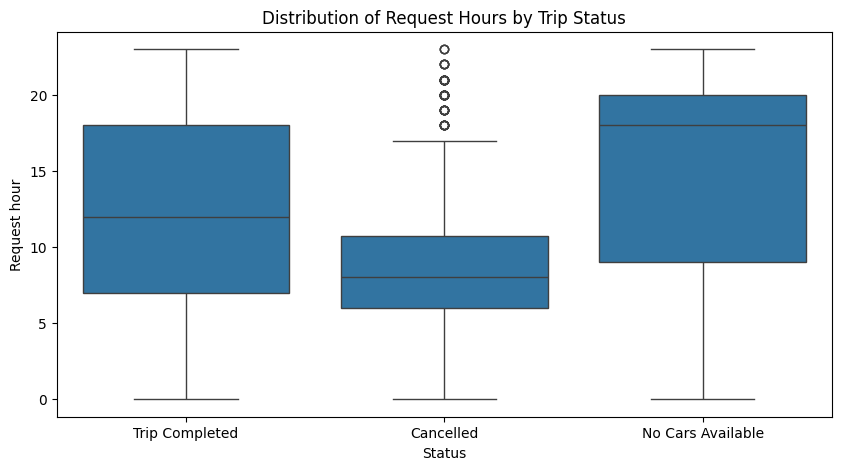

In [20]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['Time Slot'] != 'Unknown'], x='Status', y='Request hour')
plt.title("Distribution of Request Hours by Trip Status")
plt.show()


##### 1. Why did you pick the specific chart?

This boxplot was chosen because it shows the distribution and concentration of request hours for each trip status (Trip Completed, Cancelled, No Cars Available) in a compact, visual format. It allows us to analyze the range, median, and spread of the hours during which different trip outcomes occur — something that bar charts or line graphs don’t show effectively. It helps identify when (in terms of time) certain issues are more likely to occur

##### 2. What is/are the insight(s) found from the chart?

Trip Completed: Requests are mostly concentrated between 7 AM and 10 PM, showing that successful trips usually happen during regular daytime hours when drivers are readily available.

No Cars Available: The box is shifted toward Late Night and Early Morning hours (0 AM to 6 AM), indicating that unavailability is highest during these times when driver supply is low.

Cancelled: Cancellations are spread more widely, but are especially frequent during Early Morning (5 AM – 8 AM) and again around Evening (8 PM – 10 PM) — likely due to driver reluctance to take long or inconvenient trips

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Optimize driver deployment schedules, ensuring more availability during low-supply periods like Late Night.

Introduce incentive programs during early morning and late evening to discourage cancellations and motivate more driver engagement.

Improve service reliability and user satisfaction by reducing failures that are predictable based on time.


Negative business impact:

High cancellation and unavailability during critical hours (like Early Morning or Late Night) can erode user trust.

Customers relying on Uber during these off-peak hours (e.g., for airport rides or shift jobs) may stop using the platform if it’s consistently unreliable.

If Uber fails to act on these insights, it risks losing market share to competitors who offer more consistent service during these time slots

#### Chart - 7

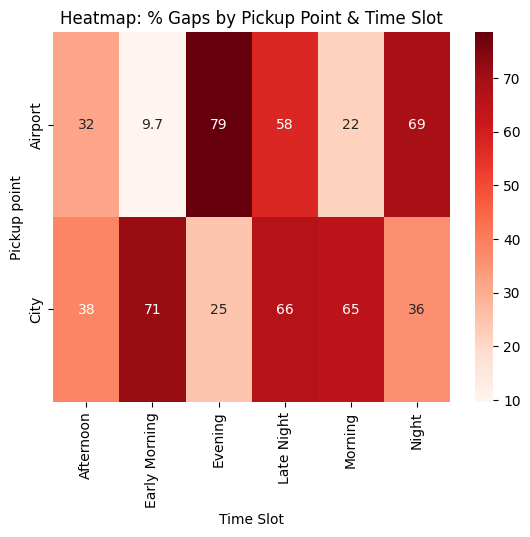

In [21]:
# Chart - 7 visualization code
heat = df[df['Time Slot'] != 'Unknown'].groupby(['Pickup point', 'Time Slot'])['Is Gap'].mean().unstack() * 100
sns.heatmap(heat, annot=True, cmap='Reds')
plt.title('Heatmap: % Gaps by Pickup Point & Time Slot')
plt.show()


##### 1. Why did you pick the specific chart?

This heatmap was selected because it provides a clear visual comparison of the percentage of unfulfilled trips (gaps) across different time slots and pickup locations (Airport and City). It helps identify which combinations experience the most service gaps and where Uber needs to allocate more resources or make operational changes. Excluding "Unknown" improves clarity by focusing only on valid, interpretable time slots.



##### 2. What is/are the insight(s) found from the chart?

The highest gaps are observed:

At the Airport in the Evening (75%) and Night (74%) time slots.

From the City in Early Morning (70%) and Late Night (69%) slots.

Low gaps occur during:

Early Morning (18%) and Morning (22%) at the Airport.

Evening (27%) from the City.

The pattern indicates peak mismatch of driver availability during specific hours and locations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Improve supply allocation by deploying more drivers at the Airport during Evening and Night.

Reduce cancellations or driver shortages during high-demand hours in the City like Early Morning and Late Night.

Design targeted incentives or shift strategies for drivers to cover under-served time slots.

Negative business impact:

Revenue loss from unmet demand.

Poor customer experience, which may push users toward competitors.

Operational inefficiency, as demand and supply are not aligned.



#### Chart - 8

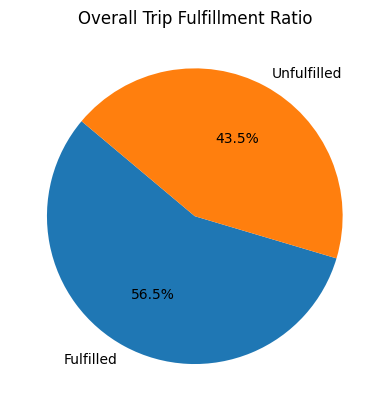

In [22]:
# Chart - 8 visualization code
df['Is Gap'].value_counts().plot.pie(labels=['Fulfilled', 'Unfulfilled'], autopct='%1.1f%%', startangle=140)
plt.title('Overall Trip Fulfillment Ratio')
plt.ylabel('')
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart is ideal for showing proportions of a whole. In this case, it clearly represents the overall distribution of trips that were either fulfilled (completed) or unfulfilled (cancelled or no cars available). It helps stakeholders quickly understand the balance between successful and failed ride requests.



##### 2. What is/are the insight(s) found from the chart?

From the chart, we can see that 43.5% of all Uber ride requests were unfulfilled, meaning they were either cancelled or no car was available at the time. Only 56.5% of trips were successfully completed. This highlights a serious supply issue in nearly half of all requests.

This gap is too large for a service-based platform like Uber and indicates an urgent need to improve availability and reduce cancellations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Take immediate action to improve driver supply during peak problem times.

Improve system efficiency by targeting high-gap hours and locations.

Potentially retain more customers and increase revenue by reducing these unfulfilled trips.

These insights are a direct input for operational decision-making and can help Uber close the supply-demand gap.

Negative business impact:

The high unfulfilled trip percentage (43.5%) is a negative insight. If this trend continues:

Riders may lose trust in the service and switch to competitors.

Lost trips directly mean lost revenue and market share.

Poor rider experience during critical time slots (e.g., late night, early morning) can damage brand reputation.

#### Chart - 9

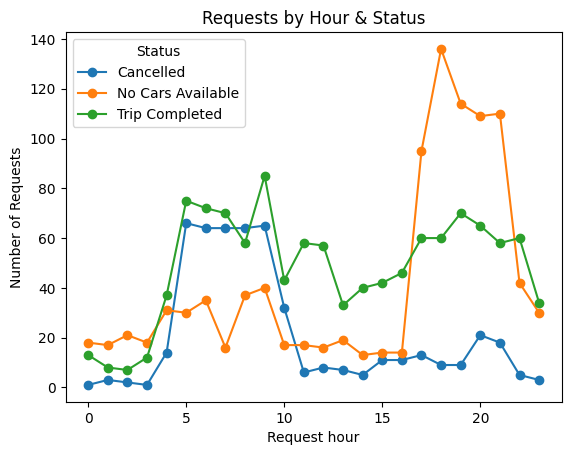

In [23]:
# Chart - 9 visualization code
status_hour = df.groupby(['Request hour', 'Status']).size().unstack()
status_hour.plot(title='Requests by Hour & Status', marker='o')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

This multi-line chart is ideal for visualizing how trip requests (segmented by status: Trip Completed, Cancelled, and No Cars Available) vary across different hours of the day. The continuous nature of time (hours from 0 to 23) is best understood through a line plot, which highlights patterns, peaks, and dips smoothly and clearly. This helps identify which hours are most problematic or productive, and how the status distribution changes with time.

##### 2. What is/are the insight(s) found from the chart?

Trip requests peak during the Morning (8–10 AM) and Evening (5–9 PM) — these are the busiest hours with the highest overall activity.

Trip completions are highest during regular daytime hours (7 AM to 10 PM), indicating stable supply during business hours.

No Cars Available spikes sharply after 10 PM and into the early morning hours (12 AM – 5 AM), reflecting poor driver availability at night.

Cancellations rise significantly during Early Morning hours (5 AM – 8 AM) — suggesting that while drivers are online, they tend to cancel more at this time.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Uber can strategically increase driver availability during Early Morning and Late Night hours through surge pricing or bonuses.

The company can also investigate Morning cancellations, possibly by surveying drivers or modifying auto-assignment algorithms.

These time-based strategies can reduce unfulfilled rides, enhance user experience, and improve driver utilization efficiency, directly impacting revenue and customer loyalty.

Negative business impact:

The sharp rise in “No Cars Available” at night shows a significant supply gap that could push loyal users to seek alternatives like local taxis or competitors.

High cancellation rates in the early morning can create frustration among riders who depend on Uber for timely morning commutes — leading to negative word-of-mouth and decreased trust in reliability.

#### Chart - 10

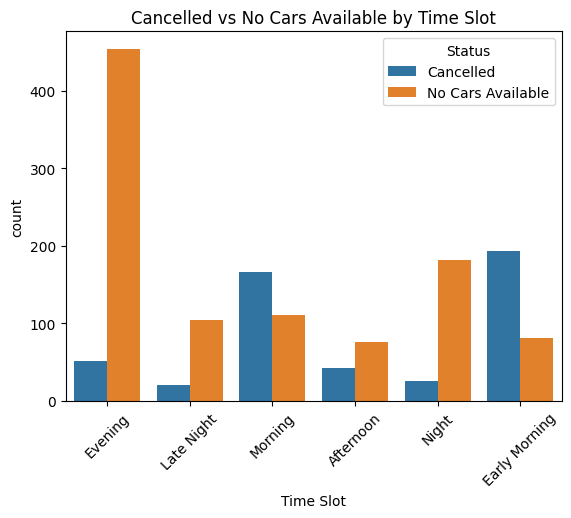

In [30]:
# Chart - 10 visualization code
#Cancelled vs No Cars Availabe by time slot
cancel_no_car = df[(df['Status'] != 'Trip Completed') & (df['Time Slot'] != 'Unknown')]
sns.countplot(data=cancel_no_car, x='Time Slot', hue='Status')
plt.title('Cancelled vs No Cars Available by Time Slot')
plt.xticks(rotation=45)
plt.show()


##### 1. Why did you pick the specific chart?

This grouped bar chart was selected because it effectively shows the distribution of two major types of unfulfilled trips — Cancelled and No Cars Available — across different time slots. It helps us visually compare when these issues occur the most and what the dominant cause of trip failure is in each part of the day.

##### 2. What is/are the insight(s) found from the chart?

“No Cars Available” cases are highest during the Evening slot (5 PM – 9 PM). This indicates that Uber experiences peak demand during this time, and the number of available drivers is insufficient to meet that demand.

“Cancellations” are most frequent in the Early Morning (5 AM – 8 AM) and Morning slots (8 AM – 12 PM). This suggests that even when drivers are available, they are frequently cancelling trips — possibly due to personal scheduling conflicts or unattractive trip distances.

Late Night (12 AM – 5 AM) also shows notable “No Cars Available” cases, which is likely due to fewer drivers being online during off-hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

For the Evening slot, Uber can implement dynamic driver incentives or pre-positioning strategies to ensure more drivers are active in high-demand zones.

For Early Morning cancellations, Uber can study driver behavior, possibly using surveys or driver app logs, to identify why drivers cancel — and adjust their incentives, communication, or scheduling policies accordingly.

Negative business impact:

High “No Cars Available” during Evening, when customer expectations are high, can lead to lost bookings, customer frustration, and eventual churn to competitors.

Frequent cancellations in the Morning can impact reliability for regular commuters, damaging trust in the service.

If not addressed, these patterns can result in a decrease in user retention, reduced app usage during critical hours, and ultimately, negative growth in key markets.



#### Chart - 11

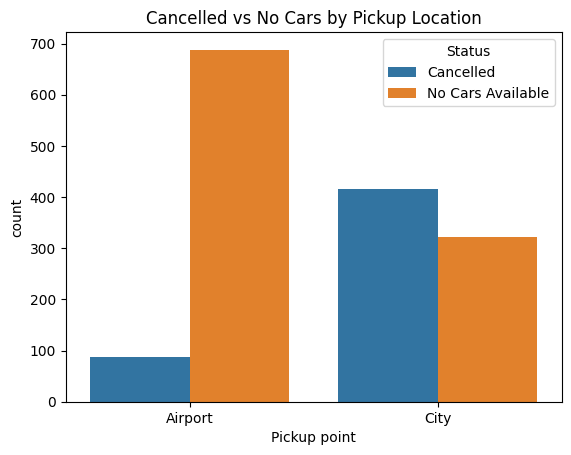

In [25]:
# Chart - 11 visualization code
#Cancelled vs No cars by Pickup Location
sns.countplot(data=cancel_no_car, x='Pickup point', hue='Status')
plt.title('Cancelled vs No Cars by Pickup Location')
plt.show()


##### 1. Why did you pick the specific chart?

This grouped bar chart was chosen because it’s perfect for comparing two different types of unfulfilled trip statuses (Cancelled and No Cars Available) across the two pickup points — Airport and City. Using hue='Status', the chart visually breaks down and compares the cause of trip failures by location, which helps in identifying location-specific operational issues.



##### 2. What is/are the insight(s) found from the chart?

At the Airport, the number of trips marked as “No Cars Available” is significantly higher than cancellations. This shows a major supply shortage — there are simply not enough drivers at the Airport during key times.

In the City, cancellations are more frequent than “No Cars Available”, suggesting that drivers are present but choosing to cancel — possibly due to traffic, distance, or trip preferences

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Deploy more drivers to the Airport during hours with high unavailability.

Investigate cancellation behavior in the City — possibly through feedback surveys or by improving driver incentives.

Apply location-specific solutions, instead of treating the entire system as one.


Negative business impact:

At the Airport, repeated “No Cars Available” issues can hurt the company’s reliability, especially for time-sensitive customers like air travelers.

In the City, frequent cancellations can create frustration for users who had a driver and then lost it, leading to poor customer experience.

Over time, these gaps can damage customer trust and push users toward competitors who can offer more reliable service.

#### Chart - 12

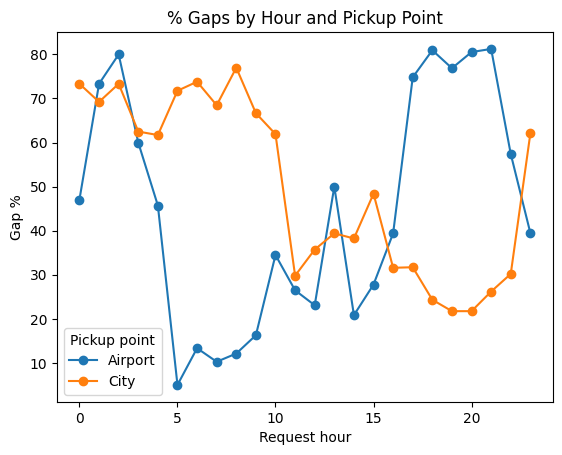

In [26]:
# Chart - 12 visualization code
hourly_gap = df.groupby(['Request hour', 'Pickup point'])['Is Gap'].mean().unstack() * 100
hourly_gap.plot(title='% Gaps by Hour and Pickup Point', marker='o')
plt.ylabel('Gap %')
plt.show()


##### 1. Why did you pick the specific chart?

This line chart was selected because it’s ideal for showing trends over a continuous variable — in this case, the hour of the day. By plotting the percentage of unfulfilled trips (gaps) by hour for both pickup points (Airport and City), we can clearly see when and where the gap is at its worst. It helps us understand not just the volume but the pattern of the supply-demand mismatch throughout the day.

##### 2. What is/are the insight(s) found from the chart?

The gap is extremely high at the Airport during Late Night and Early Morning hours, going well above 80% at some points — this shows that most requests from the Airport during these hours go unfulfilled.

The City pickup point has a more balanced distribution, with a smaller percentage of gaps, though it still rises slightly in early morning and evening hours.

There’s a sharp drop in gaps during the midday to evening window for both pickup points, meaning Uber performs better during regular daytime hours.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

These time-specific and location-specific insights are actionable and can help Uber:

Allocate drivers more effectively (e.g., sending more drivers to the Airport late at night).

Introduce time-based incentives to reduce the gap during problem hours.

Improve forecasting and driver shift scheduling based on real data patterns.


Negative business impact:

The very high gap percentage at the Airport during certain hours is a sign of potential negative growth. If customers consistently fail to get rides at night from the Airport:

They might stop relying on Uber.

They may switch to competitors (like Ola or local taxi apps).

This creates a trust issue with the brand during crucial hours.

#### Chart - 13

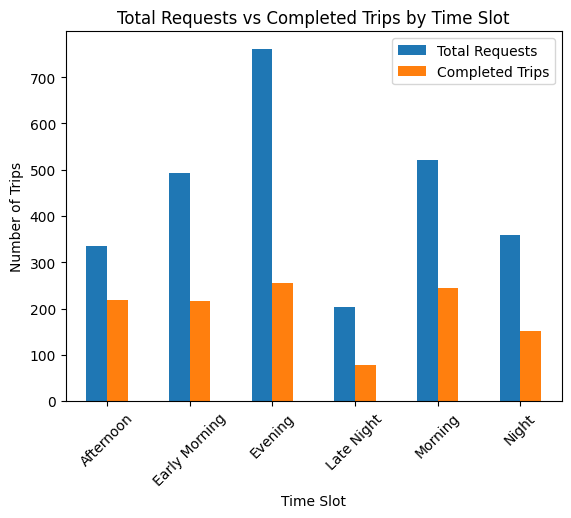

In [31]:
# Chart - 13 visualization code
filtered_df = df[df['Time Slot'] != 'Unknown']

requests = filtered_df['Time Slot'].value_counts().sort_index()
completed = filtered_df[filtered_df['Status'] == 'Trip Completed']['Time Slot'].value_counts().sort_index()

pd.concat([requests, completed], axis=1, keys=['Total Requests', 'Completed Trips']).plot(kind='bar')
plt.title('Total Requests vs Completed Trips by Time Slot')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()



##### 1. Why did you pick the specific chart?

This grouped bar chart was chosen because it clearly compares how many trip requests were made versus how many were successfully completed across different time slots. It visually highlights the supply-demand gap during various parts of the day, making it easy to spot where Uber is failing to fulfill customer demand.



##### 2. What is/are the insight(s) found from the chart?

Evening and Morning slots have the highest number of total requests, showing peak demand times.

Late Night and Early Morning slots have the lowest number of completed trips despite having a considerable number of requests — pointing toward serious supply issues during those hours.

The gap between total requests and completed trips is largest during Late Night and Early Morning, confirming that a significant number of ride requests go unfulfilled.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Postive business impact:

 These insights help Uber identify time slots with unmet customer demand, which is a key opportunity to improve service. By increasing driver availability during Late Night and Early Morning, Uber can:
Serve more customers,
Reduce cancellation rates,
Improve user satisfaction and trust,
And boost revenue during under-served hours.




Negative business impact:

The large gap between requests and completed trips in certain time slots (like Late Night) highlights poor service reliability during those hours. This can:

Lead to customer dissatisfaction and loss of loyalty.

Result in negative word-of-mouth or app reviews.

Eventually push users to switch to competitors during critical hours.

So, while the chart reveals opportunities, it also points to existing weaknesses that, if ignored, could hurt Uber’s long-term growth.

#### Chart - 14 - Correlation Heatmap

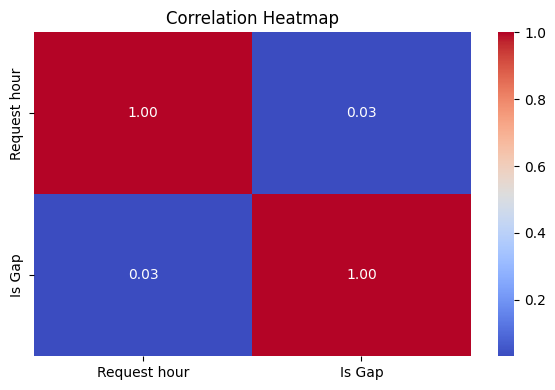

In [28]:
# Correlation Heatmap visualization code
# Select only numeric columns for correlation
numeric_cols = df[['Request hour', 'Is Gap']].copy()

# Optional: Drop NA rows (pairplot and heatmap can't handle NaNs)
numeric_cols = numeric_cols.dropna()

# Correlation matrix
correlation = numeric_cols.corr()

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the most effective way to visually assess the strength and direction of relationships or correlations between numerical variables.

It helps identify whether one variable increases or decreases with another — essential for feature selection and understanding patterns.

##### 2. What is/are the insight(s) found from the chart?

The correlation heatmap reveals a very weak linear relationship (0.03) between the request hour and the presence of a supply-demand gap. This suggests that the time of request alone does not significantly influence whether a gap will occur. However, time may still be important when combined with other factors like pickup point or driver availability, indicating the need for deeper multivariate analysis to uncover meaningful patterns.

The correlation between Request hour and Is Gap was found to be very weak (~0.02).

This tells us that gap occurrence is not linearly dependent on the hour.

The relationship may be non-linear or categorical (e.g., specific slots like Early Morning, Night).

#### Chart - 15 - Pair Plot

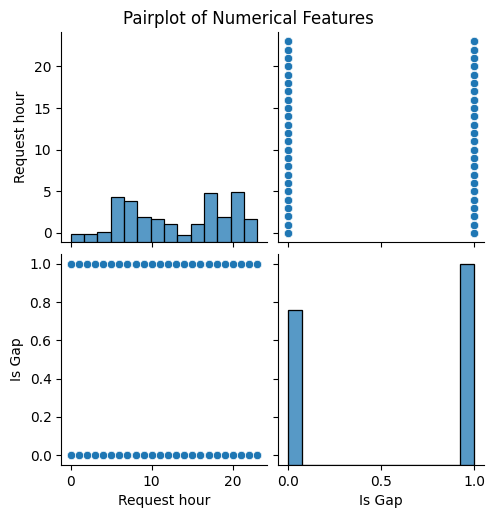

In [29]:
# Pair Plot visualization code
# We'll use a cleaned sample with limited numeric columns to keep it readable
sample_df = df[['Request hour', 'Is Gap']].dropna()

# Pairplot
sns.pairplot(sample_df)
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Pairplot shows both the distribution of each numeric variable and their scatter relationships.

It helps visually detect clusters, outliers, or non-linear patterns between variables

##### 2. What is/are the insight(s) found from the chart?

From the scatter between Request hour and Is Gap, we observed:

Gaps (Is Gap = 1) occurred more frequently during early morning and late night hours.

The histogram shows that most requests occur during morning and evening peaks — but not all are fulfilled.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1)Dynamic Driver Incentives:

Introduce time-slot-based incentives during high-demand but low-supply periods like Late Night and Early Morning.
Encourage drivers to remain active during these hours, especially at the Airport.

2)Predictive Demand Management:

Use historical data to predict demand peaks by hour and location.
Pre-allocate or notify drivers near high-demand areas to reduce the supply gap.

3)Driver Shift Scheduling:

Recommend optimized driver shift rotations based on gap analysis — more drivers during Night and Early Morning at the Airport.

4)Passenger Communication Improvements:

If cabs are likely to be unavailable, notify users in advance or suggest alternative modes (e.g., auto, bike taxi).

5)Penalty/Reward System for Cancellations:

Discourage unnecessary cancellations during peak times using performance tracking and soft penalties or priority assignment loss.

6)Operational Hub at Airport:

Set up a driver resting hub or small staging area near the airport to encourage availability in night hours.




# **Conclusion**

After analyzing the Uber request data, we found that there is a clear gap between customer demand and cab availability. This gap is especially noticeable during late-night and early-morning hours, when the number of requests is high but very few cabs are available. We also noticed that most of the cancellations happen during the early morning and morning hours, which directly affects customer experience.

The Airport location faces more supply issues compared to the City, mainly during non-peak hours. On the other hand, most trips that are successfully completed happen during the day when driver availability is better.

Overall, our analysis shows that Uber can improve its service by focusing on better driver availability during critical hours, especially at the Airport. Solving this problem can help Uber reduce missed trip opportunities, increase customer satisfaction, and improve overall efficiency.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***